In [240]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", message="findfont: *")

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


## Eda

In [218]:
archivo = "../data/raw/housing.csv" 
df = pd.read_csv(archivo, sep=",")
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [219]:
df = df[["MedInc", "Latitude", "Longitude"]]
df

,MedInc,Latitude,Longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24
3,5.6431,37.85,-122.25
4,3.8462,37.85,-122.25
...,...,...,...
20635,1.5603,39.48,-121.09
20636,2.5568,39.49,-121.21
20637,1.7000,39.43,-121.22
20638,1.8672,39.43,-121.32


In [220]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MedInc     20640 non-null  float64
 1   Latitude   20640 non-null  float64
 2   Longitude  20640 non-null  float64
dtypes: float64(3)
memory usage: 483.9 KB


In [221]:
df.duplicated().sum()

np.int64(5)

In [222]:
df = df.drop_duplicates()

In [223]:
df.duplicated().sum()

np.int64(0)

In [224]:
df.shape

(20635, 3)

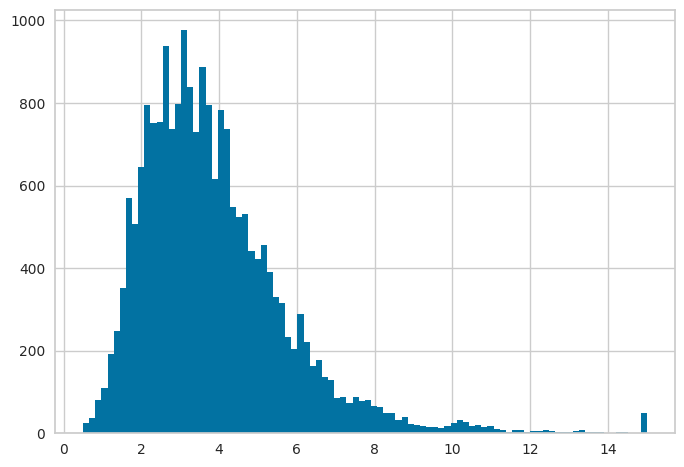

In [225]:
plt.hist(df["MedInc"].dropna(), bins="auto")
plt.show()

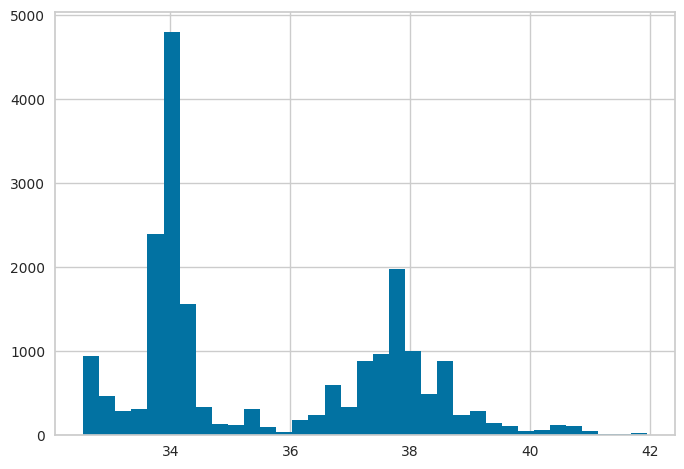

In [226]:
plt.hist(df["Latitude"].dropna(), bins="auto")
plt.show()

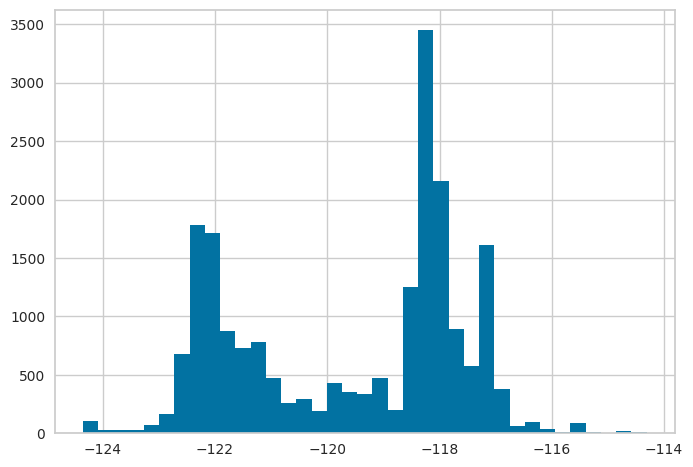

In [227]:
plt.hist(df["Longitude"].dropna(), bins="auto")
plt.show()

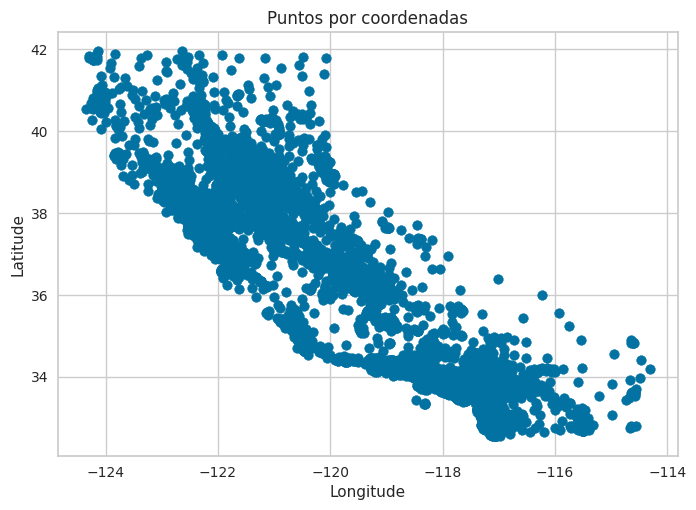

In [228]:
plt.scatter(df["Longitude"], df["Latitude"])
plt.title("Puntos por coordenadas")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## Entrenamiento de modelo

In [229]:
# Escalado de valores Min-Max.
min_max_scaler = MinMaxScaler()
min_max_features = min_max_scaler.fit_transform(df)
df_escalado = pd.DataFrame(min_max_features,
                          index=df.index,
                          columns=df.columns)
df_escalado

,MedInc,Latitude,Longitude
0,0.539668,0.567481,0.211155
1,0.538027,0.565356,0.212151
2,0.466028,0.564293,0.210159
3,0.354699,0.564293,0.209163
4,0.230776,0.564293,0.209163
...,...,...,...
20635,0.073130,0.737513,0.324701
20636,0.141853,0.738576,0.312749
20637,0.082764,0.732200,0.311753
20638,0.094295,0.732200,0.301793


In [230]:
df.columns

Index(['MedInc', 'Latitude', 'Longitude'], dtype='object')

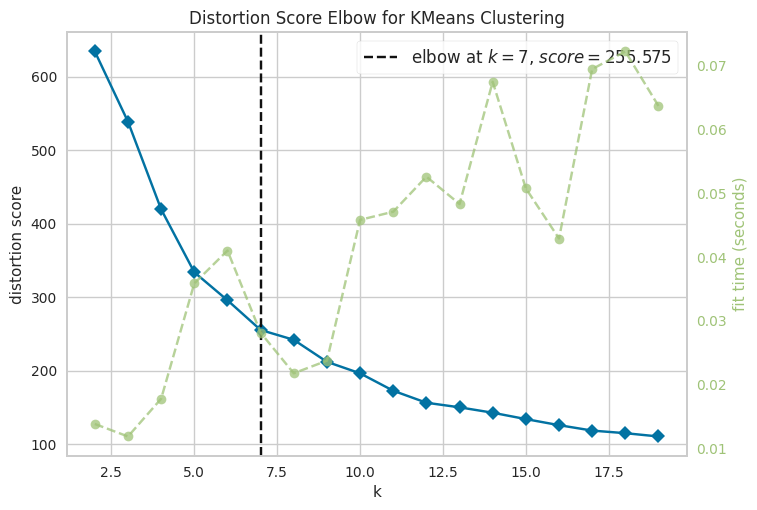

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [231]:
elbow_vis = KElbowVisualizer(KMeans(random_state=18), k=(2, 20))
elbow_vis.fit(df_escalado)
elbow_vis.show()

In [232]:
kmeans = KMeans(n_clusters=6, random_state=18)
cluster = kmeans.fit_predict(df_escalado)
cluster

array([4, 4, 4, ..., 1, 1, 1], shape=(20635,), dtype=int32)

In [233]:
df_escalado["cluster"] = cluster
df_escalado

,MedInc,Latitude,Longitude,cluster
0,0.539668,0.567481,0.211155,4
1,0.538027,0.565356,0.212151,4
2,0.466028,0.564293,0.210159,4
3,0.354699,0.564293,0.209163,4
4,0.230776,0.564293,0.209163,1
...,...,...,...,...
20635,0.073130,0.737513,0.324701,1
20636,0.141853,0.738576,0.312749,1
20637,0.082764,0.732200,0.311753,1
20638,0.094295,0.732200,0.301793,1


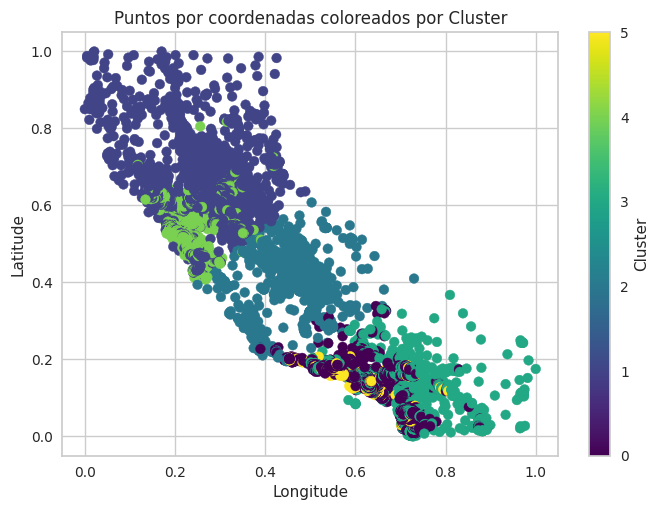

In [234]:
scatter = plt.scatter(
                    df_escalado["Longitude"], df_escalado["Latitude"],
                    c=df_escalado["cluster"], cmap='viridis')

plt.title("Puntos por coordenadas coloreados por Cluster")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

cbar = plt.colorbar(scatter)
cbar.set_label('Cluster') 

plt.show()

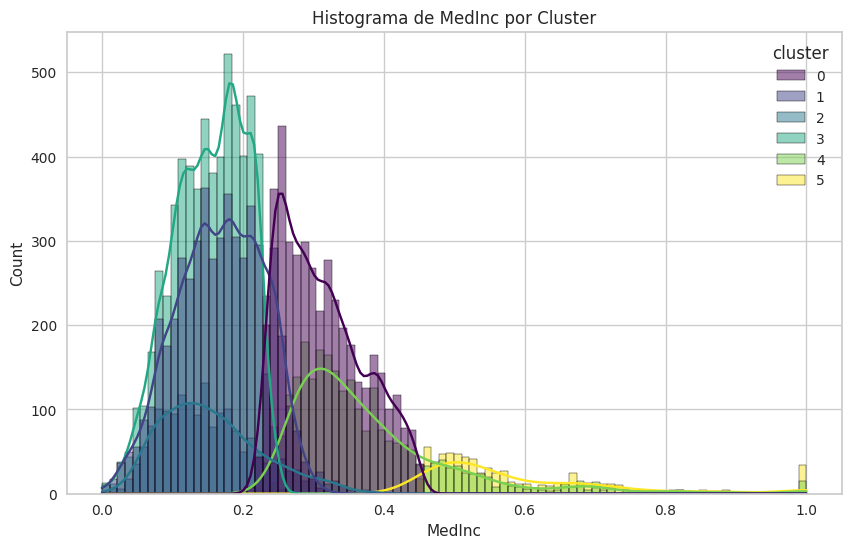

In [235]:
plt.figure(figsize=(10, 6))


sns.histplot(data=df_escalado, x="MedInc", hue="cluster", kde=True, palette="viridis")

plt.title("Histograma de MedInc por Cluster")
plt.show()

## Observaciones

> El modelo clasifico basandose en la cantidad de ingreso medio que tiene cada casa. En los casos donde la cantidad de ingreso eran identicos el se enfoco en usar latitud y longitud para asignarle un grupo. Dejandonos grupos segun zonas y ingresos medios.

## Entrenamos modelo de clasificacion para verificar resultados.

In [237]:
# Dividimos el conjunto de datos en muestras de train y test
X = df_escalado.drop("cluster", axis=1)
y = df_escalado["cluster"]

# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)

In [239]:
model = DecisionTreeClassifier(max_depth = 5, random_state = 18)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,18
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [241]:
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)
accuracy_score(y_train, y_pred_train)

0.9823116064938212

In [242]:
accuracy_score(y_test, y_pred_test)

0.9801308456505936

## Observaciones

> Es un modelo bastante sencillo y usamos un arbol de decision para analizarlo. El Test y el Train nos dieron valores bastante optimos, lo que nos indica que el modelo parece ser bastante bueno.